# Linear Models for Regression
    Messiah Ataey

In [1]:
# standard imports and configurations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style('whitegrid')
%matplotlib inline

    Linear models predict using a linear function of the input features:
    
    ŷ = w[0] * x[0] + w[1] * x[1] + ... + w[p] * x[p] + b

#### Ordinary Least Squares

    Ordinary least squares is the simplest method for regression. It evaluates the parameters w and b of the above equation that minimize the mean squared error between predictions and ground-truth labels.

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mglearn.datasets import make_wave, load_extended_boston

# sample one-dimensional dataset 
X, y = make_wave(n_samples=45)
# partition dataset into train and test subsets; affix random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=22)
# instantiate linear regression class and fit model on training data
ols = LinearRegression().fit(X_train, y_train)

In [3]:
# view attributes derived from the training data
print('Coefficients w: {0}'.format(ols.coef_))
print('Intercept b: {0}'.format(ols.intercept_))

Coefficients w: [0.50951875]
Intercept b: 0.04896058487295224


In [4]:
# view training and test scores (coefficient of determination, R^2)
print('Training score: {:.2f}'.format(ols.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ols.score(X_test, y_test)))

Training score: 0.71
Test set score: 0.44


    Based on the training and test scores, the model is underfitting the data. This is because the model is too simple, and is insufficient in capturing the particularities of the dataset. However, while this model does not perform well on low-dimensional datasets, linear models become more powerful as the number of features grow:

In [5]:
# load a dataset with a large number of features
X, y = load_extended_boston()

# view the shape of the feature space in 2D (104 features)
X.shape

(506, 104)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=22)
ols = LinearRegression().fit(X_train, y_train)

In [7]:
print('Training set score: {:.2f}'.format(ols.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ols.score(X_test, y_test)))

Training set score: 0.93
Test set score: 0.73


    Although the linear regression model this time around performed quite well on the training set compared to the one-dimensional dataset explored earlier, there is evidently a large discrepancy between the training and test scores. In contrast to the previous example where the model was underfitting the data, the linear regression model in this example overfits the data. The model tries too hard to imitate the finer-grained details of the training data and hence tends to be more representative of the peculiar noise properties of the data rather than its underlying distribution. Hence, an alternative solution is required that enables one to control model complexity. The Ridge and Lasso variants of the classic linear regression model address this.

#### Ridge Regression

    Ridge regression relies on the same approach as before to make predictions, but in this case an additional constraint is applied (the L2-norm) that acts as a way to control model complexity. The purpose of this constraint is to force the algorithm to choose a set of values (w) for the input features (x) that are diffuse (i.e., spread out) rather than one that is concentrated on a small(er) number of features. This process of penalizing the coefficient vector is referred to as regularization. The parameter which controls the degree to which the constraint is applied in these regularized regression algorithms in scikit-learn is called alpha. A large alpha results in a set of values for the coefficients that are dispersed across multiple coefficients, resulting in a less complex (or in other words more restrictive) model, and vice-versa.

In [8]:
from sklearn.linear_model import Ridge

# instantiate class and try default parameters (alpha=1.0)
ridge_default = Ridge().fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge_default.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge_default.score(X_test, y_test)))

Training set score: 0.86
Test set score: 0.83


    As shown above, the training score of Ridge is lower than that of the ordinary least squares model, while the test score is higher. This confirms the intuition that Ridge will reduce overfitting at the expense of worse training accuracy. Since we are only interested the ability of a model to generalize (i.e., perform well on new, unseen data), we should choose Ridge over the ordinary least squares model.

In [9]:
# ridge with alpha=10
ridge_alpha10 = Ridge(alpha=10).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge_alpha10.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge_alpha10.score(X_test, y_test)))

Training set score: 0.76
Test set score: 0.76


In [10]:
# ridge with alpha=0.1
ridge_alpha01 = Ridge(alpha=0.1).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge_alpha01.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge_alpha01.score(X_test, y_test)))

Training set score: 0.90
Test set score: 0.84


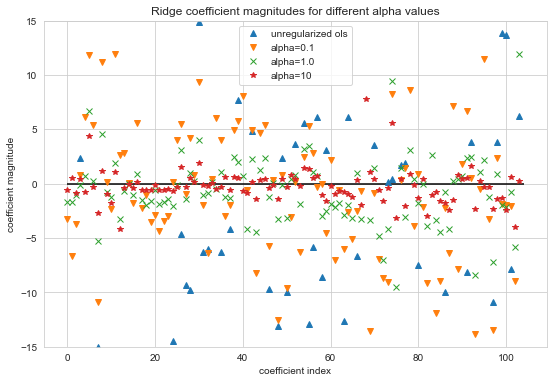

In [11]:
# plot the magnitudes of the set of Ridge coefficients for different values of alpha
fig, ax = plt.subplots(1, figsize=(9, 6), 
                       subplot_kw={
                                   'xlabel':'coefficient index', 
                                   'ylabel':'coefficient magnitude', 
                                   'title':'Ridge coefficient magnitudes for different alpha values'
                                   })
ax.hlines(0, 0, len(ols.coef_))
ax.set_ylim(-15, 15)

plt.plot(ols.coef_, '^', label='unregularized ols')
plt.plot(ridge_alpha01.coef_, 'v', label='alpha=0.1')
plt.plot(ridge_default.coef_, 'x', label='alpha=1.0')
plt.plot(ridge_alpha10.coef_, '*', label='alpha=10')

plt.legend(loc='best')

    From this graph, we can see that for larger values of alpha, the coefficient magnitudes tend to become small. Hence, larger values of alpha results in a less complex model, wheras lower values for alpha allows the coefficient magnitudes to vary signficantly, hence the model is less restricted (or in other words more complex). Notice that for low values of alpha, the model tends to behave similarly to the unregularized ordinary least squares method.

#### Lasso Regression

    Lasso regression is similar to Ridge regression but instead applies a slightly different constraint (L1-norm). Due to geometric properties, one peculiar property of Lasso is that it forces some of the coefficient magnitudes to become sparse (i.e., exactly zero). Like before, this complexity can be controlled by the alpha parameter.

In [12]:
from sklearn.linear_model import Lasso

# try various values of alpha with Lasso and see the number of features not reduced to zero
lasso_default = Lasso(alpha=1.0).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(lasso_default.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lasso_default.score(X_test, y_test)))
print('Number of features used: {0}'.format(np.sum(lasso_default.coef_ != 0)))

Training set score: 0.26
Test set score: 0.24
Number of features used: 3


In [13]:
lasso_alpha01 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(lasso_alpha01.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lasso_alpha01.score(X_test, y_test)))
print('Number of features used: {0}'.format(np.sum(lasso_alpha01.coef_ != 0)))

Training set score: 0.88
Test set score: 0.81
Number of features used: 34


In [14]:
lasso_alpha0001 = Lasso(alpha=0.0001, max_iter=100000).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(lasso_alpha0001.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lasso_alpha0001.score(X_test, y_test)))
print('Number of features used: {0}'.format(np.sum(lasso_alpha0001.coef_ != 0)))

Training set score: 0.93
Test set score: 0.78
Number of features used: 96


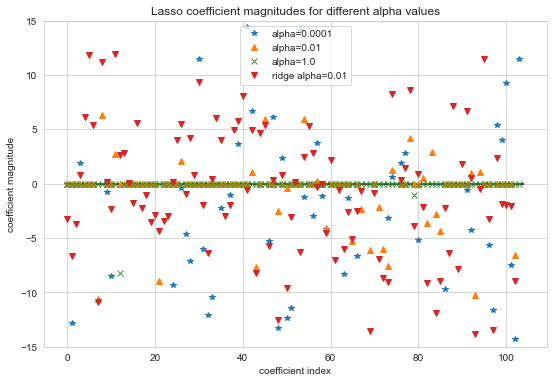

In [15]:
# plot the magnitudes of the set of Lasso coefficients for different values of alpha
fig, ax = plt.subplots(1, figsize=(9, 6), 
                       subplot_kw={
                                   'xlabel':'coefficient index', 
                                   'ylabel':'coefficient magnitude', 
                                   'title':'Lasso coefficient magnitudes for different alpha values'
                                   })
ax.hlines(0, 0, len(ols.coef_))
ax.set_ylim(-15, 15)

plt.plot(lasso_alpha0001.coef_, '*', label='alpha=0.0001')
plt.plot(lasso_alpha01.coef_, '^', label='alpha=0.01')
plt.plot(lasso_default.coef_, 'x', label='alpha=1.0')
plt.plot(ridge_alpha01.coef_, 'v', label='ridge alpha=0.01')

plt.legend(loc='best')

    Based on the above graph, we can see that Lasso is more sensitive to the alpha parameter than Ridge. Moreover, we observe that many coefficients are reduced to zero for highly regularized Lasso models; hence, it peforms a crude form of feature selection, which can be useful if model interpretability is important.